# Generate Responsed Signal from Different Sources

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from gwspace.Waveform import waveforms
from gwspace.response import get_y_slr_td, trans_y_slr_fd, get_XYZ_td, tdi_XYZ2AET
from gwspace.Orbit import detectors
from gwspace.constants import DAY, YRSID_SI, MONTH

GWSpace supports generating waveforms of multiple sources, each kind of sources has its own class to store source parameters. These classes can be called either directly or through the dictionary `Waveform.waveforms`:

In [2]:
print(waveforms)

{'burst': <class 'gwspace.Waveform.BurstWaveform'>, 'bhb_PhenomD': <class 'gwspace.Waveform.BHBWaveform'>, 'bhb_EccFD': <class 'gwspace.Waveform.BHBWaveformEcc'>, 'gcb': <class 'gwspace.Waveform.GCBWaveform'>, 'emri': <class 'gwspace.Waveform.EMRIWaveform'>, 'ringdown': <class 'gwspace.Waveform.RingdownWaveform'>}


## Galaxy Compact Binary (GCB)

GWSpace provides a simple analytical expression of time-domain GCB waveform under small frequency evolution approximation.

In [3]:
GCBpars = {"mass1": 0.5,
           "mass2": 0.5,
           "DL": 0.3,
           "phi0": 0.0,
           "f0": 0.001,
           "psi": 0.2,
           "iota": 0.3,
           "Lambda": 0.4,
           "Beta": 1.2,
           "T_obs": 10*DAY,  # YRSID_SI / 4
           }

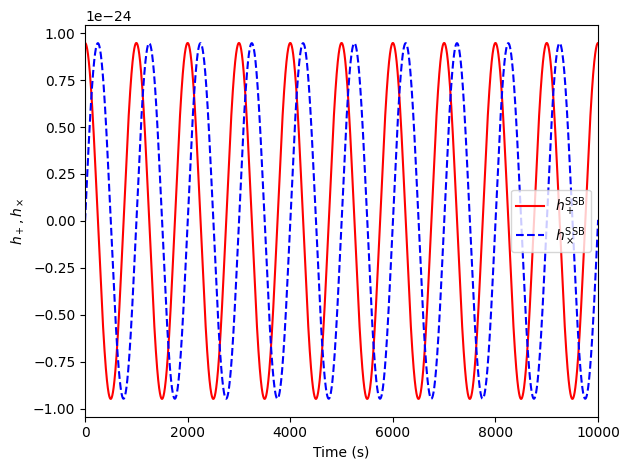

In [4]:
delta_t = 1.
tf = np.arange(0, GCBpars['T_obs'], delta_t)

GCBwf = waveforms['gcb'](**GCBpars)
hpssb, hcssb = GCBwf.get_hphc(tf)

plt.figure()
plt.plot(tf, hpssb, 'r-', label=r'$h_+^{\rm SSB}$')
plt.plot(tf, hcssb, 'b--', label=r'$h_\times^{\rm SSB}$')
plt.xlabel("Time (s)")
plt.ylabel(r"$h_+, h_\times$")
plt.xlim(0, 10000)  # let's zoom into a small range
plt.legend(loc="best")
plt.tight_layout()

In [5]:
def generate_td_data(pars, t_array, s_type='gcb', det='LISA', show_y_slr=False):
    print(f"Generating {s_type} waveforms")
    wf = waveforms[s_type](**pars)
    if show_y_slr:
        # Here is the example of how to check single arm response
        st = time.time()
        y_slr = get_y_slr_td(wf, t_array, det)
        ed = time.time()
        print(f"Time cost: {ed-st:.3f}s for {tf.shape[0]} points")

        tags = [(1, 2), (2, 1), (1, 3), (3, 1), (2, 3), (3, 2)]
        for i, tag in enumerate(tags):
            plt.figure()
            for j in range(4):
                plt.subplot(4, 1, j+1)
                plt.plot(tf, y_slr[tag][j])
                plt.title(f"y_{tag} [{j}]L")

    st = time.time()
    X, Y, Z = get_XYZ_td(wf, tf, det)
    A, E, T = tdi_XYZ2AET(X, Y, Z)
    # You can directly use get_AET_td() if you want AET channel only
    ed = time.time()
    print(f"Time cost of calculating XYZ and AET with y_slr: {ed-st:.3f}s")

    plt.subplots(2, 3, sharex='all', sharey='all')
    for i, (d, label) in enumerate(zip((X, Y, Z, A, E, T), "XYZAET")):
        plt.subplot(2, 3, i+1)
        plt.plot(tf[:-5], d[:-5])
        plt.xlabel("Time (s)")
        plt.ylabel("h")
        plt.title(label)
    plt.tight_layout()

Generating gcb waveforms
Time cost of calculating XYZ and AET with y_slr: 1.113s


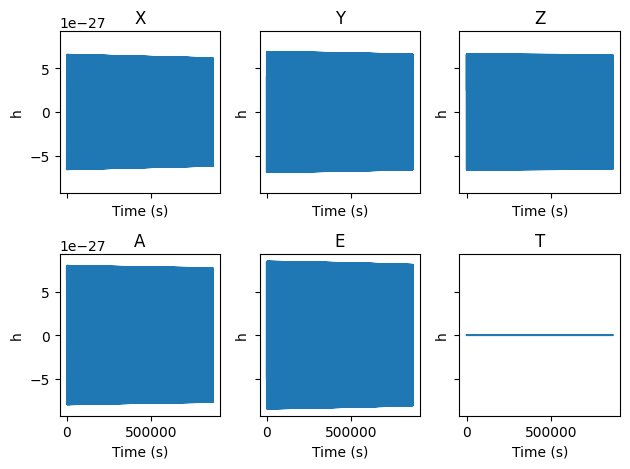

In [8]:
generate_td_data(GCBpars, tf, show_y_slr=False)

### FastGB: GCB waveform from fast/slow decomposition

GWSpace also adopt FastGB from `Galaxy` in the Mock LISA Data Challenge (MLDC). It uses a fast/slow decomposition of the waveform to reduce the computational cost, see arXiv:0704.1808 for more details.

Now take J0806 (Orientation of TianQin detector orbit) as an example:

In [10]:
def generate_fastgb(dt=1., oversample=1, show_td=False):
    # dt = 15.  # 1s for TianQin, 15s for LISA
    pars = {"mass1": 0.5,
            "mass2": 0.5,
            'T_obs': YRSID_SI*2,
            "phi0": 3.1716561,
            "f0": 0.00622028,
            "fdot": 7.48528554e-16,
            "psi": 2.91617795,
            "iota": 0.645772,
            "Lambda": 2.10225,  # ecliptic longitude [rad] J0806
            "Beta": -0.082205,  # ecliptic latitude [rad]
            }
    fastB = waveforms['gcb'](**pars)

    st = time.time()
    f, X, Y, Z = fastB.get_fastgb_fd_single(dt, oversample, detector='TianQin')
    ed = time.time()
    print(f"time cost is {ed-st}s")

    plt.figure()
    plt.loglog(f, np.abs(X), label='X')
    plt.loglog(f, np.abs(Y), label='Y')
    plt.loglog(f, np.abs(Z), label='Z')
    plt.xlim(0.00620, 0.00624)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('h')
    plt.tight_layout()

    if show_td:
        st = time.time()
        t, X, Y, Z = fastB.get_fastgb_td(dt, oversample, detector='TianQin')
        ed = time.time()
        print(f"time cost is {ed-st}s")

        plt.figure()
        plt.plot(t, X, label='X')
        plt.plot(t, Y, label='Y')
        plt.plot(t, Z, label='Z')
        plt.tight_layout()

time cost is 0.0010445117950439453s


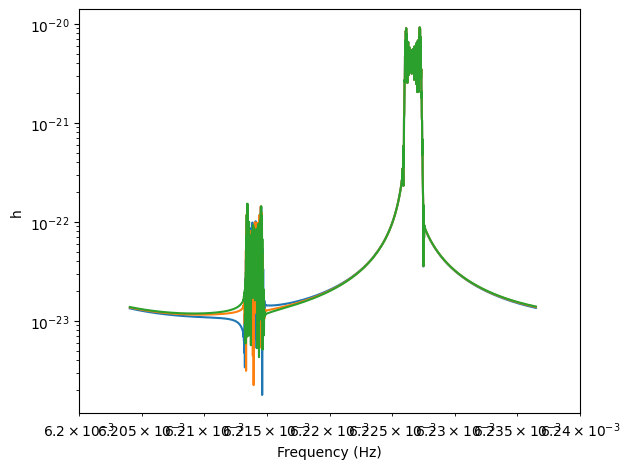

In [11]:
generate_fastgb()

## Extreme Mass Ratio Inspiral (EMRI)

GWSpace uses [FastEMRIWaveforms](https://github.com/BlackHolePerturbationToolkit/FastEMRIWaveforms) for EMRI. However, **you need to install it manually.**

In [9]:
EMRIpars = {'M': 1e6,  # Mass of larger black hole in solar masses
            'mu': 1e1,  # Mass of compact object in solar masses
            'a': 0.1,  # Dimensionless spin of massive black hole, will be ignored in Schwarzschild waveform
            'p0': 12.0,
            'e0': 0.2,
            'x0': 1.0,  # will be ignored in Schwarzschild waveform
            'qS': 0.3,  # polar sky angle
            'phiS': 0.3,  # azimuthal viewing angle
            'qK': 0.2,  # polar spin angle
            'phiK': 0.2,  # azimuthal viewing angle
            'dist': 1.0,  # Luminosity distance in Gpc
            'Phi_phi0': 1.0,
            'Phi_theta0': 2.0,
            'Phi_r0': 3.0,
            'psi': 0.4,
            'iota': 0.2,
            'T_obs': MONTH,
            }

In [10]:
EMRIpars = {
    'M':  4.3e6,   # [修正] 中心大黑洞质量：430万倍太阳质量 (Wang et al. 2023)
    'mu': 40.0,    # [修正] 伴星小黑洞质量：40倍太阳质量 (Wang et al. 2023)
    'a':  0.1,     # [建议] 中心黑洞自旋：Wang文建议低自旋，也可根据需要设为0
    'p0': 9.0,     # [修正] 轨道半通径 (对应圆轨道半径)：9 Rg (GRAVITY观测值)
    'e0': 0.0,     # [修正] 偏心率：0 (假设轨道已圆化)
    'x0': 1.0,     # 轨道倾角余弦 (对于圆轨道通常设为1或根据具体几何设定)
    
    # --- 天空位置 (Sgr A* 的固定坐标) ---
    # Sgr A* 位于银心，需转换为黄道坐标 (Ecliptic Coordinates)
    # 大致位置：Long ≈ 270度, Lat ≈ -5.6度
    'qS':   1.66,  # 极角 (Polar angle) ≈ 90 - (-5.6) = 95.6度 ≈ 1.66 rad
    'phiS': 4.71,  # 方位角 (Azimuthal) ≈ 270度 ≈ 4.71 rad
    
    'qK':   0.2,   # 自旋极角 (保持默认或根据模型调整)
    'phiK': 0.2,   # 自旋方位角 (保持默认或根据模型调整)
    
    'dist': 8.0e-6, # [！！！关键修正！！！] 距离：8 kpc 转换为 Gpc
                    # 8 kpc = 0.008 Mpc = 0.000008 Gpc
    
    'Phi_phi0': 1.0,
    'Phi_theta0': 2.0,
    'Phi_r0': 3.0,
    'psi': 0.4,
    'iota': 0.2,    # 轨道倾角 (相对于视线，可设为 Wang 文提到的 ~130度 或 0.5 rad)
    
    'T_obs': 5 * YRSID_SI, #
}

In [11]:
def generate_td_data(pars, t_array, s_type='gcb', det='TQ', show_y_slr=False):
    print(f"Generating {s_type} waveforms")
    wf = waveforms[s_type](**pars)
    if show_y_slr:
        # Here is the example of how to check single arm response
        st = time.time()
        y_slr = get_y_slr_td(wf, t_array, det)
        ed = time.time()
        print(f"Time cost: {ed-st:.3f}s for {tf.shape[0]} points")

        tags = [(1, 2), (2, 1), (1, 3), (3, 1), (2, 3), (3, 2)]
        for i, tag in enumerate(tags):
            plt.figure()
            for j in range(4):
                plt.subplot(4, 1, j+1)
                plt.plot(tf, y_slr[tag][j])
                plt.title(f"y_{tag} [{j}]L")

    st = time.time()
    X, Y, Z = get_XYZ_td(wf, tf, det)
    A, E, T = tdi_XYZ2AET(X, Y, Z)
    # You can directly use get_AET_td() if you want AET channel only
    ed = time.time()
    print(f"Time cost of calculating XYZ and AET with y_slr: {ed-st:.3f}s")

    plt.subplots(2, 3, sharex='all', sharey='all')
    for i, (d, label) in enumerate(zip((X, Y, Z, A, E, T), "XYZAET")):
        plt.subplot(2, 3, i+1)
        plt.plot(tf[:-5], d[:-5])
        plt.xlabel("Time (s)")
        plt.ylabel("h")
        plt.title(label)
    plt.tight_layout()

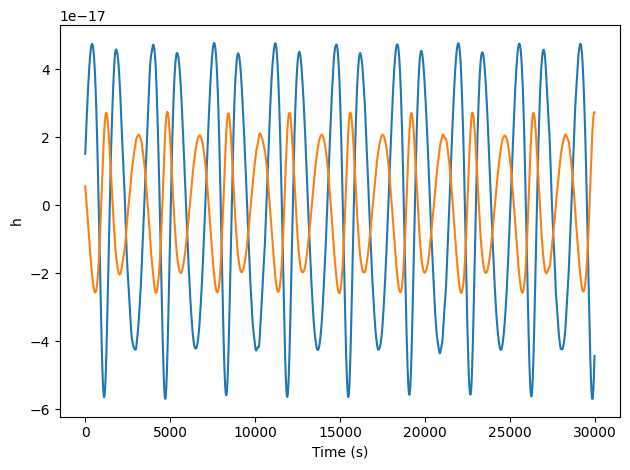

In [12]:
delta_t = 15.  # seconds
tf = np.arange(0, EMRIpars['T_obs'], delta_t)

EMRIwf = waveforms['emri'](**EMRIpars)
hp, hc = EMRIwf.get_hphc(tf)

index = 2000
plt.figure()
plt.plot(tf[:index], hp[:index])
plt.plot(tf[:index], hc[:index])
plt.xlabel('Time (s)')
plt.ylabel('h')
plt.tight_layout()

Generating emri waveforms
Time cost of calculating XYZ and AET with y_slr: 1777.000s


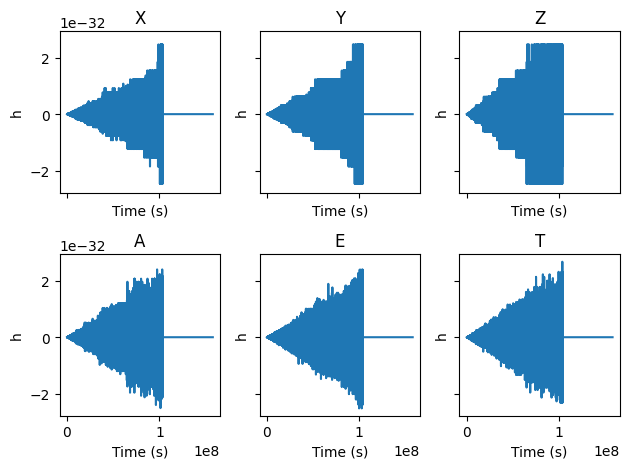

In [8]:
generate_td_data(EMRIpars, tf, s_type='emri')

## Binary Black Hole (BBH)

GWSpace supports two frequency-domain BBH waveform: IMRPhenomD and EccentricFD.


### IMRPhenomD

In [12]:
MBHBpars = {"mass1": 3.5e6,
            "mass2": 2.1e5,
            'T_obs': MONTH*3,
            "chi1": 0.2,
            "chi2": 0.1,
            "DL": 1e3,
            "psi": 0.2,
            "iota": 0.3,
            "Lambda": 0.4,
            "Beta": 1.2,
            "tc": 0,
            }

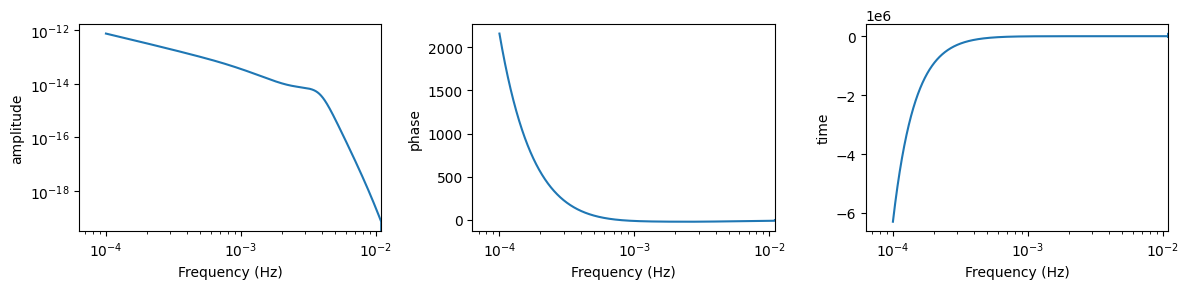

In [13]:
NF = 10240
freq = np.logspace(-4, 0, NF)

BHBwf = waveforms['bhb_PhenomD'](**MBHBpars)
amp, phase, tf = BHBwf.get_amp_phase(f_series=freq)
i_max = np.where(amp[(2, 2)] == 0)[0][0]

plt.subplots(1, 3, sharex='all', figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.loglog(freq, amp[(2, 2)])
plt.xlabel('Frequency (Hz)')
plt.ylabel('amplitude')

plt.subplot(1, 3, 2)
plt.semilogx(freq, phase[(2, 2)])
plt.xlabel('Frequency (Hz)')
plt.ylabel('phase')

plt.subplot(1, 3, 3)
plt.semilogx(freq, tf[(2, 2)])
plt.xlabel('Frequency (Hz)')
plt.ylabel('time')

plt.xlim(None, freq[i_max])
plt.tight_layout()

In [18]:
def generate_fd_data(pars, f_array, s_type='bhb_PhenomD', det='TQ', show_y_slr=False):
    print(f"Generating {s_type} waveforms")
    wf = waveforms[s_type](**pars)

    if show_y_slr:
        # Here is the example of how to check single arm response
        amp, phase, tf = wf.get_amp_phase(f_series=f_array)
        amp, phase, tf = amp[(2, 2)], phase[(2, 2)], tf[(2, 2)]
        h22 = amp * np.exp(1j*phase) * np.exp(2j*np.pi*f_array*wf.tc)
        det_orb = detectors[det](tf)

        st = time.time()
        y_slr = trans_y_slr_fd(wf.vec_k, wf.p_22, det_orb, f_array)[0]
        y_slr = {k: v*h22 for k, v in y_slr.items()}
        ed = time.time()
        print(f"Time cost for the fd response: {ed-st:.4f}s")

        ln = [(1, 2), (2, 1), (1, 3), (3, 1), (2, 3), (3, 2)]
        plt.figure()
        for ll in ln:
            plt.loglog(freq, np.abs(y_slr[ll]), label=ll)
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('h')
        plt.legend()
        plt.tight_layout()

    X, Y, Z = wf.get_tdi_response(f_series=f_array, channel='XYZ', det=det)
    A, E, T = wf.get_tdi_response(f_series=f_array, channel='AET', det=det)

    plt.figure()
    plt.loglog(f_array, np.abs(X), '-', label='X')
    plt.loglog(f_array, np.abs(Y), '-', label='Y')
    plt.loglog(f_array, np.abs(Z), '-', label='Z')
    plt.loglog(f_array, np.abs(A), '--', label='A')
    plt.loglog(f_array, np.abs(E), '--', label='E')
    plt.loglog(f_array, np.abs(T), '--', label='T')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('h')
    plt.legend()
    plt.tight_layout()

Generating bhb_PhenomD waveforms
Time cost for the fd response: 0.0037s


/tmp/ipykernel_32399/1365978856.py:21: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.loglog(freq, np.abs(y_slr[ll]), label=ll)


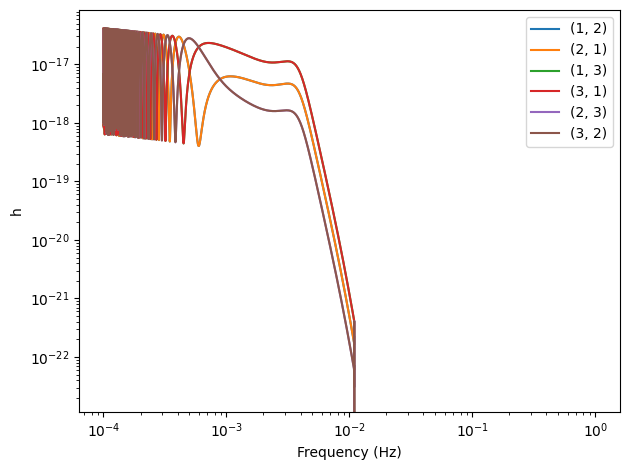

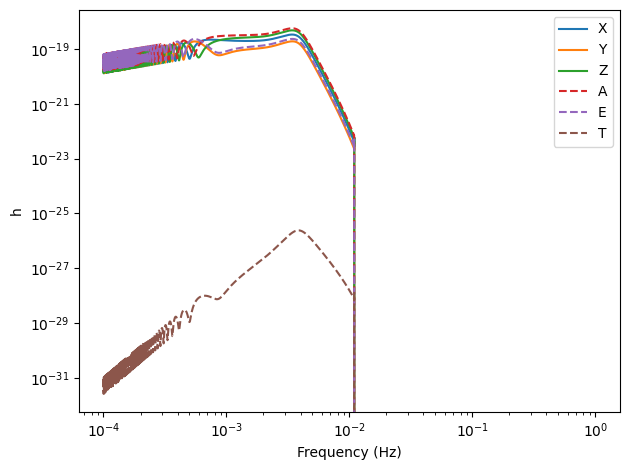

In [19]:
generate_fd_data(MBHBpars, freq, show_y_slr=True)

### EccentricFD

GWSpace also supports a [modified version](https://github.com/HumphreyWang/pyEccentricFD) of EccentricFD waveform, which is specially for space-detector responses.

Since EccentricFD is an eccentric non-spinning inspiral-only waveform, it'd better be used for stellar-mass BBHs, which will merge outside the sensitive frequency band of space detectors.

In [17]:
ecc_pars = {'DL': 100,  # Luminosity distance (Mpc)
            'mass1': 35.6,  # Primary mass (solar mass)
            'mass2': 30.6,  # Secondary mass(solar mass)
            'Lambda': 4.7,  # Longitude
            'Beta': -1.5,  # Latitude
            'phi_c': 0,  # Coalescence phase
            'T_obs': MONTH*3,  # Observation time (s)
            'tc': 0,  # Coalescence time (s)
            'iota': 0.3,  # Inclination angle
            'var_phi': 0,  # Observer phase
            'psi': 0.2,  # Polarization angle
            }  # masses of GW150914

Finished in  0.47977s 



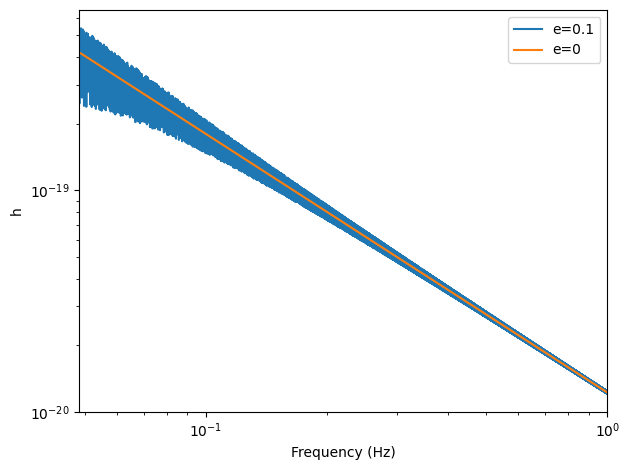

In [18]:
start_time = time.time()
delta_f = 1e-5
ecc_wf = waveforms['bhb_EccFD'](**ecc_pars, eccentricity=0.1)
hp, _ = ecc_wf.get_hphc(delta_f=delta_f)
ecc_wf0 = waveforms['bhb_EccFD'](**ecc_pars, eccentricity=0.)
hp0, _ = ecc_wf0.get_hphc(delta_f=delta_f)
print(f'Finished in {time.time() - start_time: .5f}s', '\n')

freq = delta_f * np.array(range(len(hp)))
plt.figure()
plt.loglog(freq, np.abs(hp), label='e=0.1')
plt.loglog(freq, np.abs(hp0), label='e=0')
plt.xlim(ecc_wf.f_min, 1)
plt.xlabel('Frequency (Hz)')
plt.ylabel('h')
plt.legend()
plt.tight_layout()

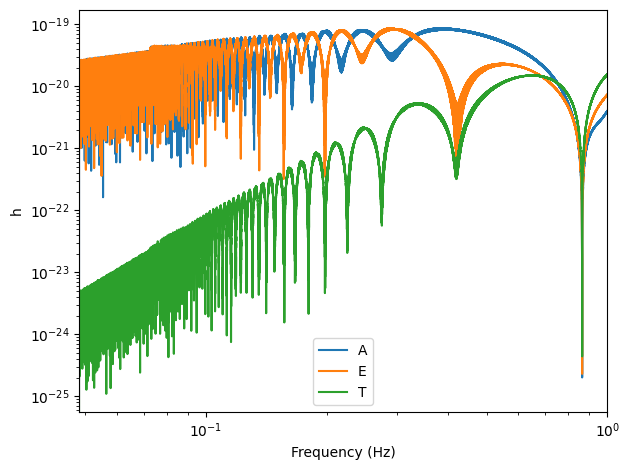

In [19]:
(smBBH_A, smBBH_E, smBBH_T), freq_e = ecc_wf.get_tdi_response(delta_f=delta_f, det='TQ')

plt.figure()
plt.loglog(freq_e, np.abs(smBBH_A), label='A')
plt.loglog(freq_e, np.abs(smBBH_E), label='E')
plt.loglog(freq_e, np.abs(smBBH_T), label='T')
plt.xlabel('Frequency (Hz)')
plt.ylabel('h')
plt.xlim(ecc_wf.f_min, 1)
# plt.ylim(1e-23, 1e-16)
plt.legend()
plt.tight_layout()

## GW Burst

GWSpace provides a sin-Gaussian waveform as basic model of bursts.

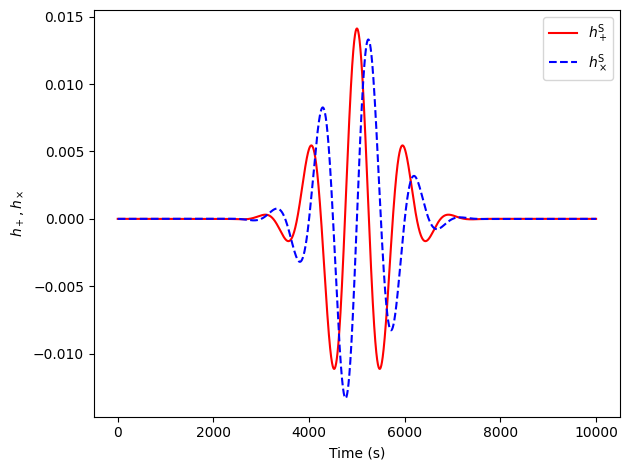

In [20]:
T_obs = 10000  # YRSID_SI / 4
delta_t = 1
tf = np.arange(0, T_obs, delta_t)

Burst = waveforms['burst'](amp=0.5, tau=1000, fc=0.001, tc=5000)
hp, hc = Burst.get_hphc(tf)

plt.figure()
plt.plot(tf, hp, 'r-', label=r'$h_+^{\rm S}$')
plt.plot(tf, hc, 'b--', label=r'$h_\times^{\rm S}$')
plt.xlabel("Time (s)")
plt.ylabel(r"$h_+, h_\times$")
plt.legend()
plt.tight_layout()

# TODO: add results after response?

## Stochastic Gravitational Wave Background (SGWB)

GWSpace also supports isotropy SGWB and SGWB from a specific orientation.

Time cost: 3.728898286819458 s
1 year SNR for SGWB: 7.463296725560229


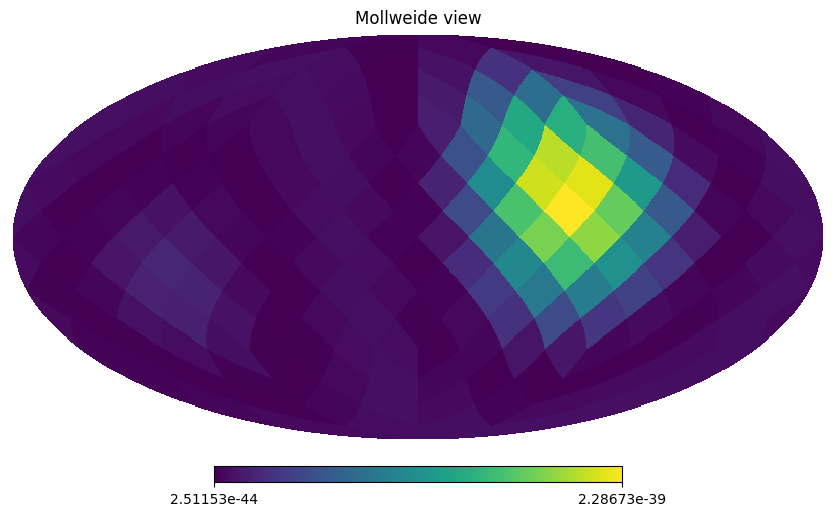

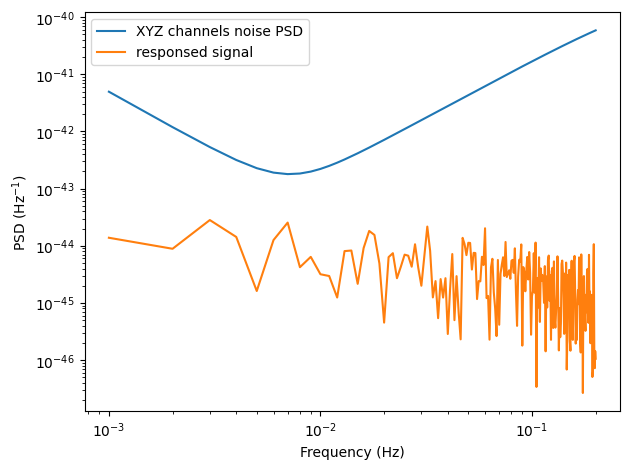

In [21]:
import healpy as hp
from gwspace.SGWB import SGWB
from gwspace.Noise import TianQinNoise

SGWBpars = {"nside": 4,
            "omega0": 5e-11,
            "alpha": 0.667,
            "T_obs": 63*5000,
            # "blm_vals": (1.0, 0.75, 0.5, 0.7j, 0.7-0.3j, 1.1j),
            # "blmax": 2,
            "theta": 1.3,
            "phi": 1.2,
            }
signal_pars = {"f_max": 0.2,
               "f_min": 0.001,
               "fn": 200,
               "t_segm": 5000,
               }
start_time = time.time()
SGWB_signal = SGWB(**SGWBpars)
res_signal, frange = SGWB_signal.get_response_signal(**signal_pars)
print(f"Time cost: {time.time()-start_time} s")

# We can first look at what the original signal looked like
signal_in_gu = SGWB_signal.get_ori_signal(frange)
hp.mollview(signal_in_gu[:, 0])

tq = TianQinNoise()
TX, TXY = tq.noise_XYZ(frange, unit="displacement")/(2e8*np.sqrt(3))**2

plt.figure()
plt.loglog(frange, TX, label="XYZ channels noise PSD")
plt.loglog(frange, np.abs(res_signal[:, 0, 0, 0]), label="responsed signal")
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (Hz$^{-1}$)')
plt.legend()
plt.tight_layout()

# TODO: add descriptions
SNR = np.sqrt(24*3600*3.64*np.sum(res_signal[:, 0, 0, 0]**2/TX**2).real/frange.size)
print("1 year SNR for SGWB:", SNR)

In [22]:
import sys, gwspace, inspect
print(sys.executable)
print(gwspace.__file__)
print(inspect.getsource(gwspace.Waveform.EMRIWaveform._gen_wave_func))

/home/sh3ng/anaconda3/envs/gwspace312/bin/python
/home/sh3ng/anaconda3/envs/gwspace312/lib/python3.12/site-packages/gwspace/__init__.py
    @staticmethod
    def _gen_wave_func():

        # from few.waveform import GenerateEMRIWaveform

        # model = "FastSchwarzschildEccentricFlux"
        # use_gpu = False
        # # keyword arguments for inspiral generator (RunSchwarzEccFluxInspiral)
        # inspiral_kwargs = {"DENSE_STEPPING": 0,  # we want a sparsely sampled trajectory
        #                    "max_init_len": int(1e3)}  # all the trajectories will be well under len = 1000
        # # keyword arguments for inspiral generator (RomanAmplitude)
        # amplitude_kwargs = {"use_gpu": use_gpu,
        #                     "max_init_len": int(1e3)}  # all the trajectories will be well under len = 1000
        # # keyword arguments for Ylm generator (GetYlms)
        # Ylm_kwargs = {"include_minus_m": True}
        # # keyword arguments for summation generator (Interpolated

In [1]:
import few

# 查看当前后端（无参数时返回已选的 backend）
try:
    print("current backend:", few.get_backend(None))
except Exception:
    print("current backend: default (CPU)")

# 如果想看可用的 GPU/CUDA：
print("has cuda12x:", few.has_backend("cuda12x"))
print("has cuda11x:", few.has_backend("cuda11x"))
print("has cpu:", few.has_backend("cpu"))

current backend: default (CPU)
has cuda12x: False
has cuda11x: False
has cpu: True


In [6]:
import cupy, few

# 1) 先让 CuPy 绑定到 0 号卡；这里不能报 cudaErrorNoDevice
cupy.cuda.runtime.setDevice(0)
print("device count:", cupy.cuda.runtime.getDeviceCount())
print("current device:", cupy.cuda.runtime.getDevice())
print("cupy test:", cupy.arange(3))

# 2) 重置 FEW 后端，并检查 cuda12x
few.utils.globals.reset(quiet=True)
print("has cuda12x:", few.has_backend("cuda12x"))
print("current backend:", few.get_backend('cuda12x'))  # 应该返回 cuda12x

device count: 1
current device: 0
cupy test: [0 1 2]
has cuda12x: True
current backend: <few.cutils.Cuda12xBackend object at 0x7f4399d50920>


In [1]:
import cupy
print("device count:", cupy.cuda.runtime.getDeviceCount())
try:
    cupy.cuda.runtime.setDevice(0)
    print("current device:", cupy.cuda.runtime.getDevice())
    print("test:", cupy.arange(3))
except Exception as e:
    import traceback; traceback.print_exc()

device count: 1
current device: 0
test: [0 1 2]


Backend: CPU (NumPy)
Generating emri waveforms
Time cost: 2.384s for 518400 points
Time cost of calculating XYZ and AET with y_slr: 1.658s


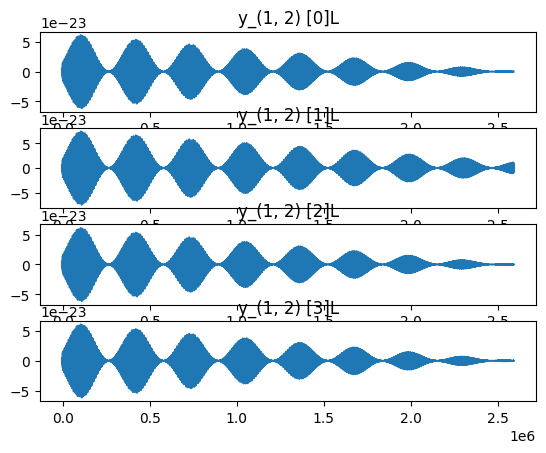

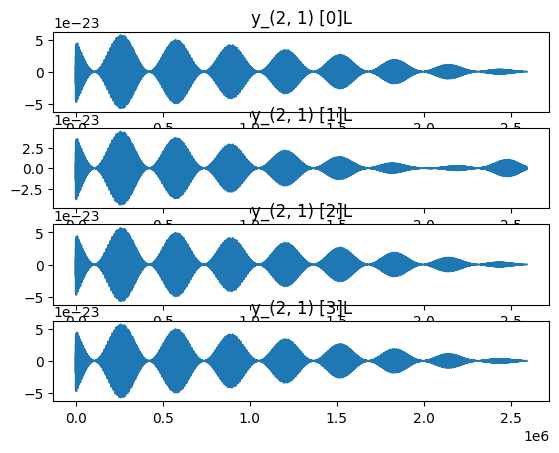

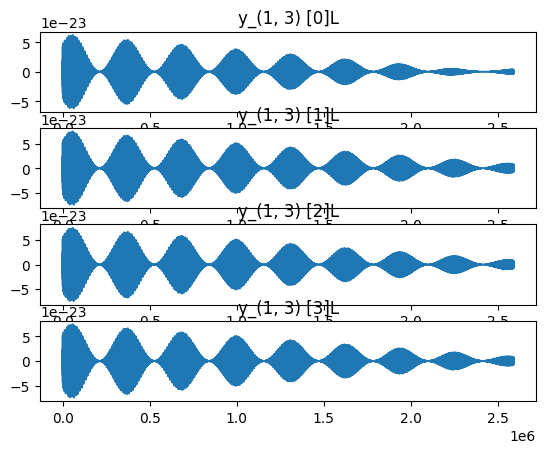

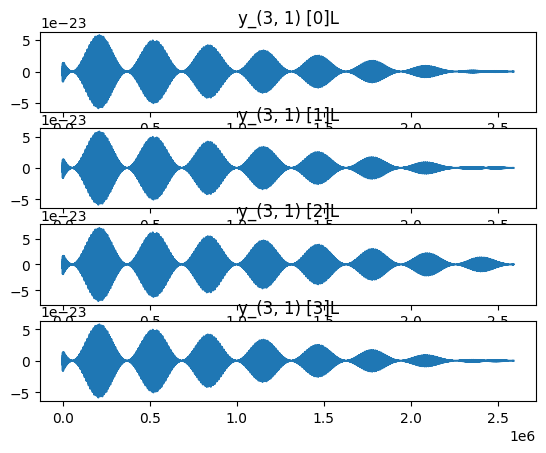

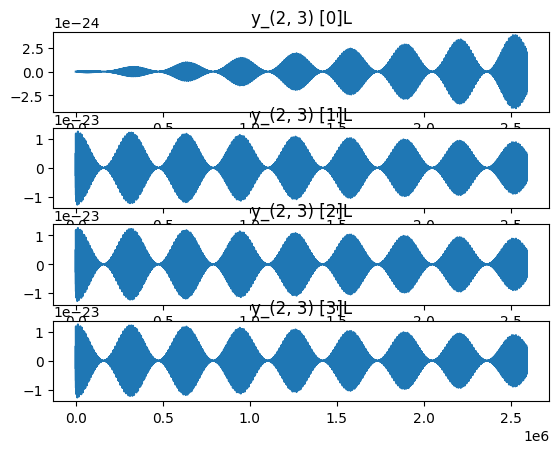

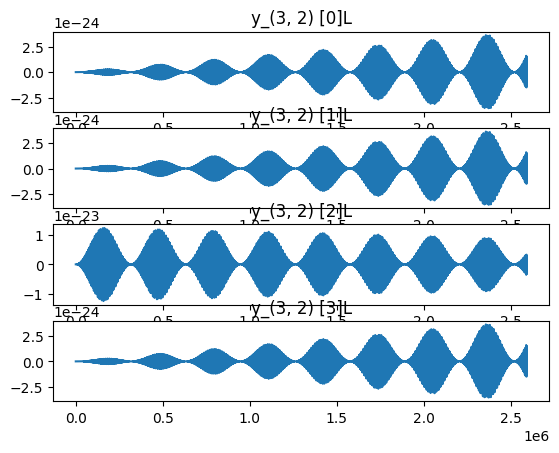

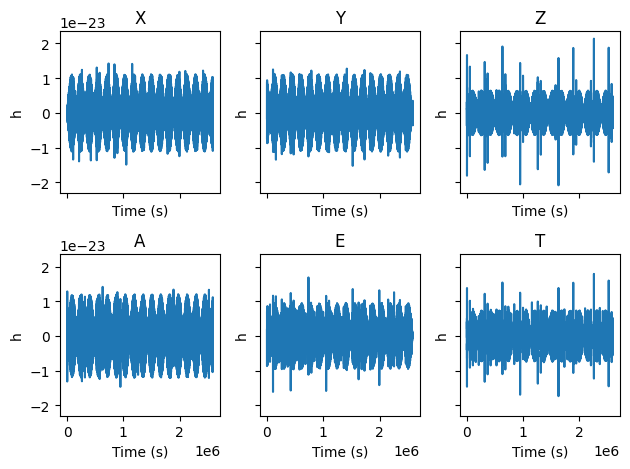

In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt

try:
    import cupy as cp
except Exception:
    cp = None

from gwspace.Waveform import waveforms
from gwspace.constants import MONTH
from gwspace.response_b import (
    get_y_slr_td,
    get_XYZ_td,
    get_AET_td,
    tdi_XYZ2AET,
)

def to_cpu(x):
    return cp.asnumpy(x) if (cp is not None and isinstance(x, cp.ndarray)) else np.asarray(x)

def generate_td_data(pars, t_array, s_type="gcb", det="TQ", show_y_slr=False, use_gpu=False):
    print(f"Backend: {'GPU (CuPy)' if use_gpu and cp is not None else 'CPU (NumPy)'}")
    print(f"Generating {s_type} waveforms")
    wf = waveforms[s_type](**pars)

    if show_y_slr:
        st = time.time()
        y_slr = get_y_slr_td(wf, t_array, det=det, use_gpu=use_gpu)
        ed = time.time()
        print(f"Time cost: {ed - st:.3f}s for {t_array.shape[0]} points")

        tags = [(1, 2), (2, 1), (1, 3), (3, 1), (2, 3), (3, 2)]
        for tag in tags:
            plt.figure()
            for j in range(4):
                plt.subplot(4, 1, j + 1)
                plt.plot(t_array, to_cpu(y_slr[tag][j]))
                plt.title(f"y_{tag} [{j}]L")

    st = time.time()
    
    X, Y, Z = get_XYZ_td(wf, t_array, det=det, TDIgen=1, use_gpu=use_gpu)
    A, E, T = tdi_XYZ2AET(X, Y, Z, use_gpu=use_gpu)
    ed = time.time()
    print(f"Time cost of calculating XYZ and AET with y_slr: {ed - st:.3f}s")

    plt.subplots(2, 3, sharex="all", sharey="all")
    for i, (d, label) in enumerate(zip((X, Y, Z, A, E, T), "XYZAET")):
        plt.subplot(2, 3, i + 1)
        plt.plot(t_array[:-5], to_cpu(d)[:-5])
        plt.xlabel("Time (s)")
        plt.ylabel("h")
        plt.title(label)
    plt.tight_layout()


# ------------------ EMRI 示例 ------------------
EMRIpars = {
    "M": 1e6,
    "mu": 1e1,
    "a": 0.1,
    "p0": 12.0,
    "e0": 0.2,
    "x0": 1.0,
    "qS": 0.3,
    "phiS": 0.3,
    "qK": 0.2,
    "phiK": 0.2,
    "dist": 1.0,
    "Phi_phi0": 1.0,
    "Phi_theta0": 2.0,
    "Phi_r0": 3.0,
    "psi": 0.4,
    "iota": 0.2,
    "T_obs": MONTH,
}

delta_t = 5.0  # seconds
tf = np.arange(0, EMRIpars["T_obs"], delta_t)

# waveform; get_hphc output may be CuPy if backend uses GPU, so convert before plotting
EMRIwf = waveforms["emri"](**EMRIpars)
hp, hc = EMRIwf.get_hphc(tf)
hp_cpu, hc_cpu = to_cpu(hp), to_cpu(hc)

# index = 2000
# plt.figure()
# plt.plot(tf[:index], hp_cpu[:index], label="h+")
# plt.plot(tf[:index], hc_cpu[:index], label="hx")
# plt.xlabel("Time (s)")
# plt.ylabel("h")
# plt.legend()
# plt.tight_layout()

# GPU-aware response (set use_gpu=False if no CuPy)
generate_td_data(EMRIpars, tf, s_type="emri", det="TQ", show_y_slr=True, use_gpu=False)


In [15]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import time
import numpy as np
import matplotlib.pyplot as plt

# 可选 CuPy
try:
    import cupy as cp
except Exception:
    cp = None

from gwspace.Waveform import waveforms
from gwspace.constants import MONTH

# 统一版 response 的导入路径（按你的安装位置来）
from gwspace.response import (
    get_y_slr_td,
    get_XYZ_td,
    get_AET_td,
    tdi_XYZ2AET,
)

def to_cpu(x):
    """把可能的 CuPy 数组转成 NumPy，方便绘图。"""
    return cp.asnumpy(x) if (cp is not None and isinstance(x, cp.ndarray)) else np.asarray(x)

def _normalize_vec_k_inplace(wf):
    """将 wf.vec_k 规范为一维(3,)。只在测试脚本里做，不改库代码。"""
    if hasattr(wf, "vec_k"):
        k = np.asarray(wf.vec_k)
        if k.size != 3:
            raise ValueError(f"wf.vec_k must have 3 elements, got shape {k.shape}")
        wf.vec_k = k.reshape(3,)

def generate_td_data(pars, t_array, s_type="gcb", det="TQ", show_y_slr=False, use_gpu=True):
    print(f"Generating {s_type} waveforms")
    wf = waveforms[s_type](**pars)
    # ✅ 规范化 vec_k，避免 einsum 形状错误
    _normalize_vec_k_inplace(wf)

    if show_y_slr:
        st = time.time()
        y_slr = get_y_slr_td(wf, t_array, det=det, use_gpu=use_gpu)
        ed = time.time()
        print(f"Time cost: {ed - st:.3f}s for {t_array.shape[0]} points")

        tags = [(1, 2), (2, 1), (1, 3), (3, 1), (2, 3), (3, 2)]
        for tag in tags:
            plt.figure()
            for j in range(4):
                plt.subplot(4, 1, j + 1)
                plt.plot(t_array, to_cpu(y_slr[tag][j]))
                plt.title(f"y_{tag} [{j}]L")

    st = time.time()
    X, Y, Z = get_XYZ_td(wf, t_array, det=det, TDIgen=1, use_gpu=use_gpu)
    A, E, T = tdi_XYZ2AET(X, Y, Z, use_gpu=use_gpu)  # 统一版也支持 use_gpu
    ed = time.time()
    print(f"Time cost of calculating XYZ and AET with y_slr: {ed - st:.3f}s")

    # 简单画图（去掉末尾少量点以避开 TDI 边界影响）
    CUT = 5  # 对于 TDIgen=1 通常够用
    plt.subplots(2, 3, sharex="all", sharey="all")
    for i, (d, label) in enumerate(zip((X, Y, Z, A, E, T), "XYZAET")):
        plt.subplot(2, 3, i + 1)
        dd = to_cpu(d)
        plt.plot(t_array[:-CUT], dd[:-CUT])
        plt.xlabel("Time (s)")
        plt.ylabel("h")
        plt.title(label)
    plt.tight_layout()

# ------------------ EMRI 示例 ------------------
EMRIpars = {
    "M": 1e6,
    "mu": 1e1,
    "a": 0.1,
    "p0": 12.0,
    "e0": 0.2,
    "x0": 1.0,
    "qS": 0.3,
    "phiS": 0.3,
    "qK": 0.2,
    "phiK": 0.2,
    "dist": 1.0,
    "Phi_phi0": 1.0,
    "Phi_theta0": 2.0,
    "Phi_r0": 3.0,
    "psi": 0.4,
    "iota": 0.2,
    "T_obs": MONTH,
}

delta_t = 15.0  # seconds
tf = np.arange(0, EMRIpars["T_obs"], delta_t)

# 直接看原始波形（用于 sanity check）
EMRIwf = waveforms["emri"](**EMRIpars)
# ✅ 可选：也把这个独立实例规范化，防止后面单独用它时再踩坑
_normalize_vec_k_inplace(EMRIwf)
hp, hc = EMRIwf.get_hphc(tf)
hp_cpu, hc_cpu = to_cpu(hp), to_cpu(hc)

# 可以解开看看原始 h+ / hx
# index = 2000
# plt.figure()
# plt.plot(tf[:index], hp_cpu[:index], label="h+")
# plt.plot(tf[:index], hc_cpu[:index], label="hx")
# plt.xlabel("Time (s)")
# plt.ylabel("h")
# plt.legend()
# plt.tight_layout()

# GPU-aware response（如果没有 CuPy 或想强制 CPU，则把 use_gpu=False）
USE_GPU = (cp is not None)
generate_td_data(EMRIpars, tf, s_type="emri", det="TQ", show_y_slr=False, use_gpu=USE_GPU)


AttributeError: property 'vec_k' of 'EMRIWaveform' object has no setter

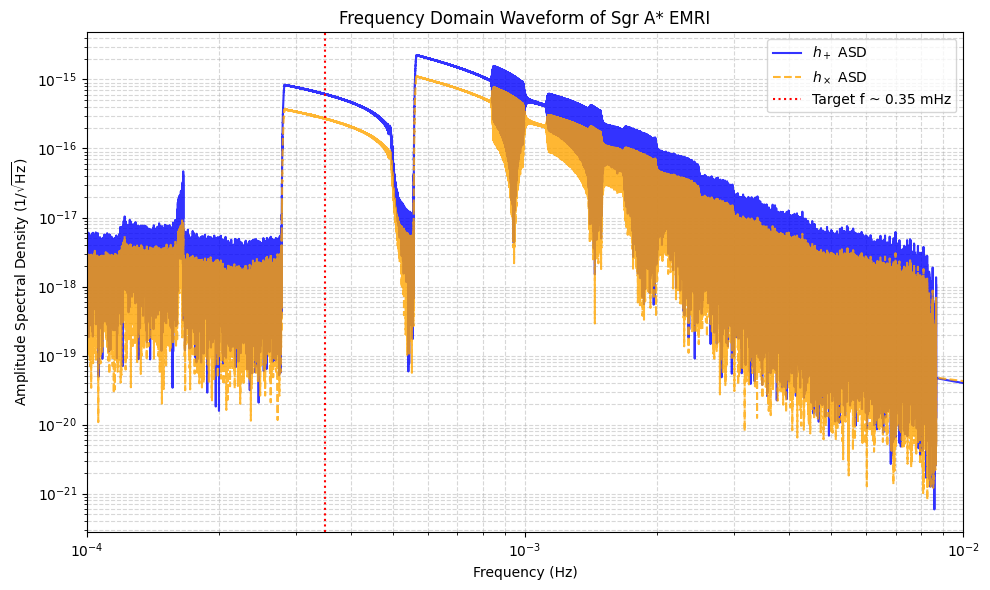

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import get_window

def compute_asd(time_series, dt):
    """
    计算单边振幅谱密度 (ASD)
    输入:
        time_series: 时域数组 (例如 hp)
        dt: 采样时间间隔 (seconds)
    输出:
        freqs: 频率数组
        asd: ASD 数组 (单位 1/sqrt(Hz))
    """
    N = len(time_series)
    
    # 1. 加窗 (Windowing)
    # 使用 Tukey 窗，既能防止边缘泄露，又保留中间大部分数据的原始振幅
    window = get_window(('tukey', 0.1), N)
    data_windowed = time_series * window
    
    # 2. 计算 FFT
    # rfft 用于实数信号，只返回正频率部分
    data_fft = np.fft.rfft(data_windowed)
    freqs = np.fft.rfftfreq(N, d=dt)
    
    # 3. 归一化 (Normalization) - 关键步骤
    # 想要得到 ASD (1/sqrt(Hz))，需要乘以归一化因子
    # 因子 = sqrt(2 * dt / N)
    # 另外需要除以窗函数的均方根值来补偿能量损失
    win_factor = np.sqrt(np.mean(window**2))
    normalization = np.sqrt(2 * dt / N) / win_factor
    
    asd = np.abs(data_fft) * normalization
    
    return freqs, asd

# --- 执行计算 ---
# 利用你已有的 hp 和 delta_t
f_axis, hp_asd = compute_asd(hp, delta_t)
f_axis, hc_asd = compute_asd(hc, delta_t)

# --- 绘图 ---
plt.figure(figsize=(10, 6))

# 绘制信号 ASD
plt.loglog(f_axis, hp_asd, label=r'$h_+$ ASD', color='blue', alpha=0.8)
plt.loglog(f_axis, hc_asd, label=r'$h_\times$ ASD', color='orange', alpha=0.8, linestyle='--')

# --- 添加辅助线和标注 ---
# 1. 标出 Sgr A* 的目标频率 (0.35 mHz)
target_freq = 0.35e-3
plt.axvline(x=target_freq, color='red', linestyle=':', label=f'Target f ~ {target_freq*1000:.2f} mHz')

# 2. 设置坐标轴范围 (聚焦在天琴关心的频段)
plt.xlim(1e-4, 1e-2)  # 0.1 mHz 到 10 mHz
# y轴范围根据信号强度自动调整，或者手动设为 [1e-20, 1e-15]

plt.xlabel('Frequency (Hz)')
plt.ylabel(r'Amplitude Spectral Density ($1/\sqrt{\rm{Hz}}$)')
plt.title('Frequency Domain Waveform of Sgr A* EMRI')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

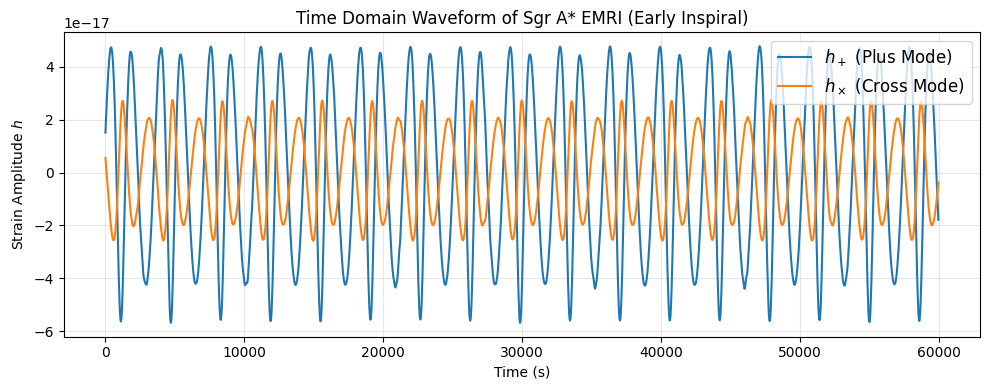

In [17]:
# ... (前面的代码保持不变) ...

index = 2000
plt.figure(figsize=(10, 4)) # 建议稍微把图拉宽一点，看起来更清晰

# 1. 在 plot 函数中加入 label 参数
# r'$...$' 是 Python 的原始字符串写法，允许在图中显示漂亮的数学符号
plt.plot(tf[:index], hp[:index], label=r'$h_+$ (Plus Mode)')
plt.plot(tf[:index], hc[:index], label=r'$h_\times$ (Cross Mode)')

plt.xlabel('Time (s)')
plt.ylabel('Strain Amplitude $h$') # 优化纵坐标标签
plt.title('Time Domain Waveform of Sgr A* EMRI (Early Inspiral)') # 加上标题

# 2. 显示图例
# loc='best' 会自动把图例放在遮挡最少的位置
plt.legend(loc='upper right', fontsize=12) 

plt.grid(True, alpha=0.3) # 加上网格会让读图更容易
plt.tight_layout()
plt.show()

正在计算 FFT...


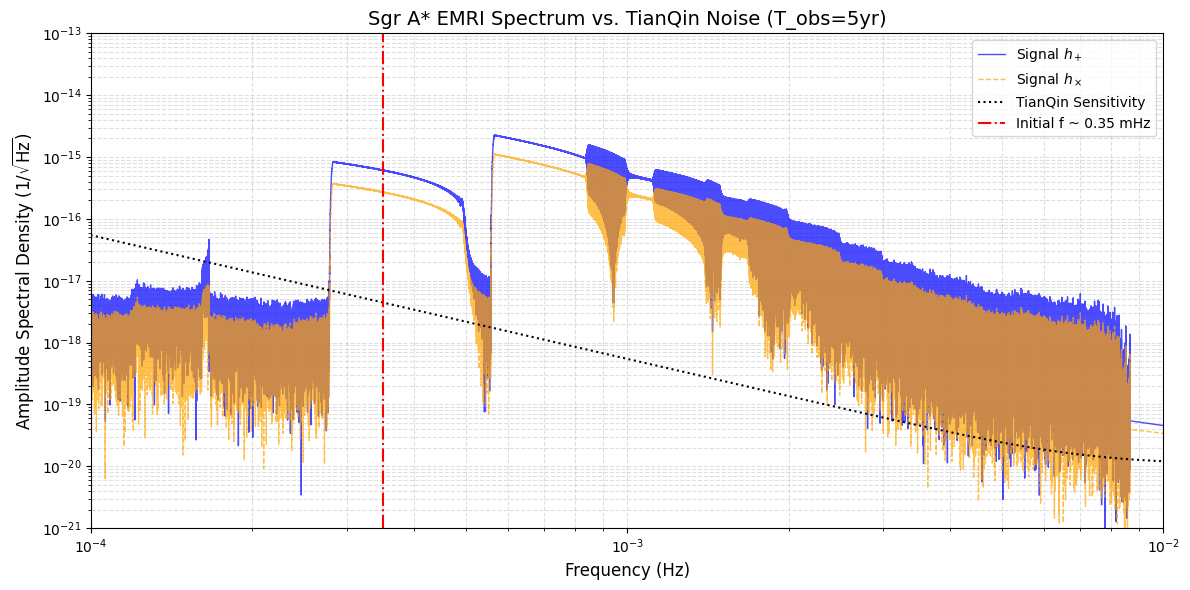

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import get_window

# ==========================================
# 1. 定义核心处理函数
# ==========================================
def get_asd(time_series, dt):
    """
    将时域波形转换为振幅谱密度 (ASD)
    输入:
        time_series: 时域数据 (如 hp 或 hc)
        dt: 采样间隔 (s)
    输出:
        freqs: 频率轴
        asd: ASD 数值 (1/sqrt(Hz))
    """
    N = len(time_series)
    
    # [关键步骤1] 加窗 (Windowing)
    # 使用 Tukey window (alpha=0.1) 防止由于非周期截断导致的“频谱泄露” (Spectral Leakage)
    # 这能让你的频谱图看起来更干净，不会有奇怪的“裙边”
    window = get_window(('tukey', 0.1), N)
    data_windowed = time_series * window
    
    # [关键步骤2] FFT 变换
    # rfft 专门用于实数输入，只计算正频率部分
    data_fft = np.fft.rfft(data_windowed)
    freqs = np.fft.rfftfreq(N, d=dt)
    
    # [关键步骤3] 归一化 (Normalization)
    # 为了得到 ASD (单位 /sqrt(Hz))，必须乘以这个系数
    # 系数 = sqrt(2 * dt / N)
    # 还要除以窗函数的均方根 (RMS) 来补偿加窗损失的能量
    win_factor = np.sqrt(np.mean(window**2))
    norm_factor = np.sqrt(2 * dt / N) / win_factor
    
    asd = np.abs(data_fft) * norm_factor
    return freqs, asd

def tianqin_sensitivity(f):
    """
    天琴的近似灵敏度曲线 (ASD)
    用于背景对比
    """
    L = 1.7e8           # 臂长 (m)
    f_star = 3e8 / (2 * np.pi * L)
    Sa = 1e-30          # 加速度噪声
    Sx = 1e-24          # 位移噪声
    
    # 避免除以0
    f = np.maximum(f, 1e-10)
    
    # PSD 公式
    Sn = (10 / (3 * L**2)) * (4 * Sa / (2 * np.pi * f)**4 + Sx) * (1 + 0.6 * (f / f_star)**2)
    return np.sqrt(Sn)

# ==========================================
# 2. 执行计算
# ==========================================
# 假设你之前已经有了 hp, hc, delta_t
print("正在计算 FFT...")
f_axis, hp_asd = get_asd(hp, delta_t)
f_axis, hc_asd = get_asd(hc, delta_t)

# 计算天琴噪声背景
tq_noise = tianqin_sensitivity(f_axis)

# ==========================================
# 3. 绘制频域图
# ==========================================
plt.figure(figsize=(12, 6))

# 绘制信号
# alpha 设置透明度，让重叠部分也能看清
plt.loglog(f_axis, hp_asd, label=r'Signal $h_+$', color='blue', alpha=0.7, linewidth=1)
plt.loglog(f_axis, hc_asd, label=r'Signal $h_\times$', color='orange', alpha=0.7, linewidth=1, linestyle='--')

# 绘制天琴灵敏度 (噪声门槛)
plt.loglog(f_axis, tq_noise, label='TianQin Sensitivity', color='black', linestyle=':', linewidth=1.5)

# 标注 Sgr A* 的初始频率
target_f = 0.35e-3
plt.axvline(x=target_f, color='red', linestyle='-.', label=f'Initial f ~ {target_f*1000:.2f} mHz')

# 设置显示范围 (聚焦在天琴最敏感的 mHz 频段)
plt.xlim(1e-4, 1e-2)  # 0.1 mHz 到 10 mHz
# 自动调整 Y 轴下限，避免显示数值噪声
plt.ylim(1e-21, 1e-13)

# 标签与美化
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel(r'Amplitude Spectral Density ($1/\sqrt{\rm{Hz}}$)', fontsize=12)
plt.title(f'Sgr A* EMRI Spectrum vs. TianQin Noise (T_obs=5yr)', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, which='both', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

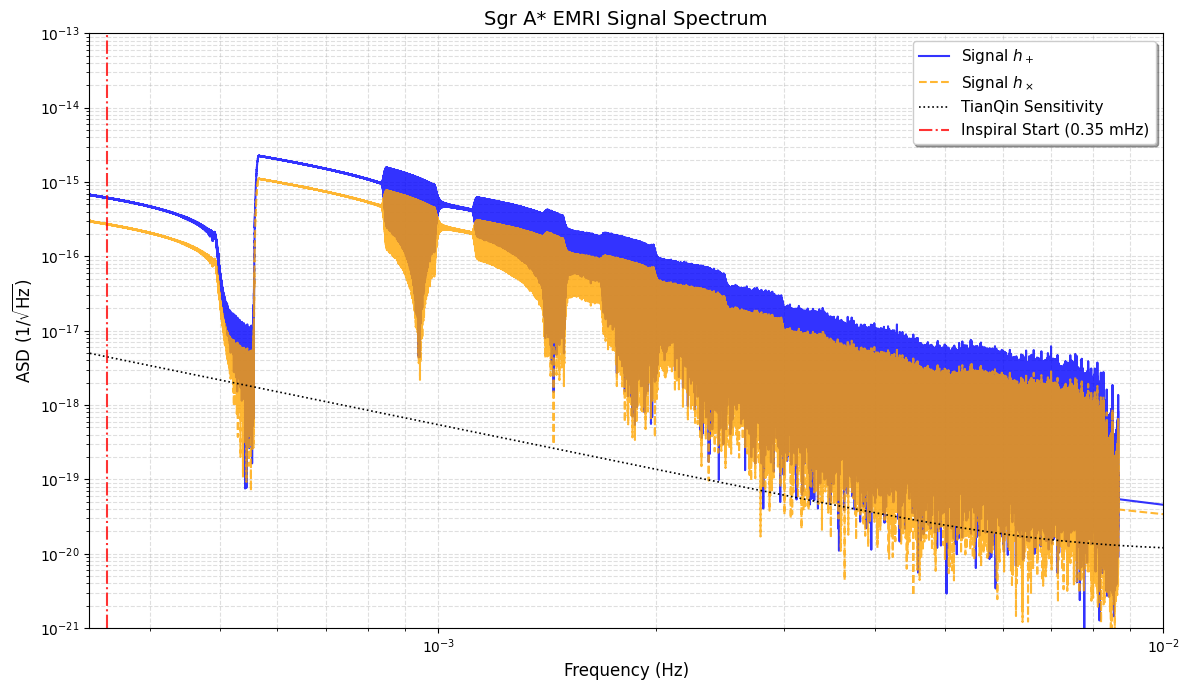

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 设置剪裁范围和关键点
# ==========================================
target_f = 0.35e-3        # 目标频率: 0.35 mHz
cut_off_f = 0.33e-3       # 剪裁频率: 稍微留点左边距

# ==========================================
# 2. 数据掩膜 (Masking)
# ==========================================
# 假设 f_axis, hp_asd, hc_asd, tq_noise 已经计算好了
mask = f_axis >= cut_off_f
f_clean = f_axis[mask]
hp_clean = hp_asd[mask]
hc_clean = hc_asd[mask]

# ==========================================
# 3. 绘图
# ==========================================
plt.figure(figsize=(12, 7))

# 绘制信号
plt.loglog(f_clean, hp_clean, label=r'Signal $h_+$', color='blue', alpha=0.8, linewidth=1.5)
plt.loglog(f_clean, hc_clean, label=r'Signal $h_\times$', color='orange', alpha=0.8, linewidth=1.5, linestyle='--')

# 绘制天琴噪声背景
plt.loglog(f_axis, tq_noise, label='TianQin Sensitivity', color='black', linestyle=':', linewidth=1.2)

# --- [关键修改] 把信息加到图例中 ---
# 在画竖线时增加 label 参数
label_text = f'Inspiral Start ({target_f*1000:.2f} mHz)'
plt.axvline(x=target_f, color='red', linestyle='-.', alpha=0.8, linewidth=1.5, label=label_text)

# (移除了之前的 annotate 代码块)

# ==========================================
# 4. 调整视野和图例
# ==========================================
plt.xlim(cut_off_f, 1e-2)      # X轴范围
plt.ylim(1e-21, 1e-13)         # Y轴范围

plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel(r'ASD ($1/\sqrt{\rm{Hz}}$)', fontsize=12)
plt.title(f'Sgr A* EMRI Signal Spectrum', fontsize=14)

# 显示图例 (自动包含红线的信息)
# loc='upper right' 确保它在右上方
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)

plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

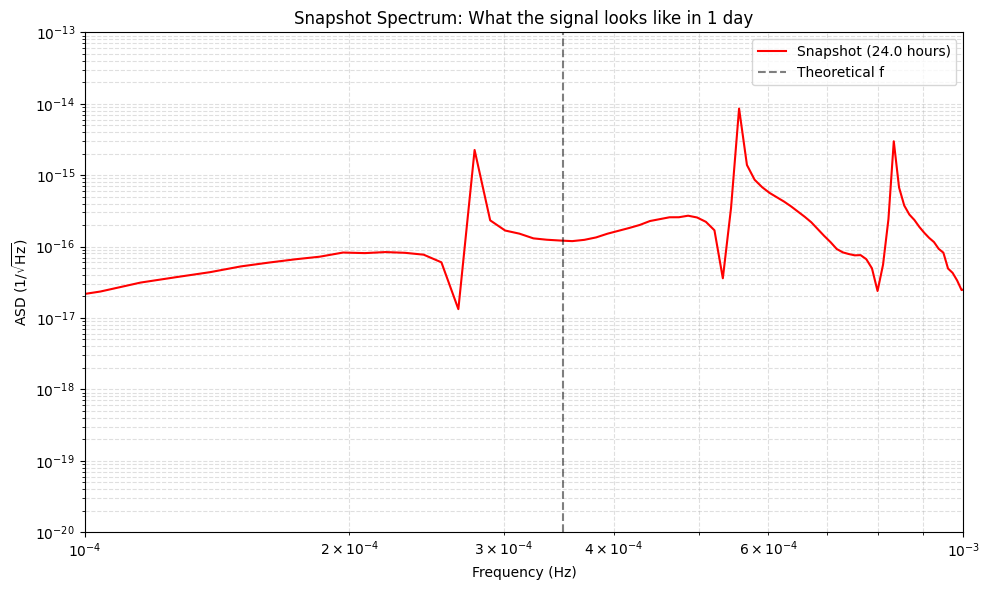

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import get_window

# ==========================================
# 1. 设置“快照”时长
# ==========================================
# 我们想看哪个时刻的频谱？
# 比如：只看观测开始后的第 1 天 (86400秒)
snapshot_duration = 1.0 * 24 * 3600  # [秒]
n_slice = int(snapshot_duration / delta_t)

# 截取这一小段数据 (从 t=0 开始)
# 如果你想看第 4 年的，可以用 hp[start_index : end_index]
hp_snapshot = hp[:n_slice]
hc_snapshot = hc[:n_slice]

# ==========================================
# 2. 计算短时 ASD (Short-term ASD)
# ==========================================
def compute_snapshot_asd(data, dt):
    N = len(data)
    window = get_window(('tukey', 0.1), N)
    data_fft = np.fft.rfft(data * window)
    freqs = np.fft.rfftfreq(N, d=dt)
    
    # 归一化 (注意这里 N 变小了，分辨率变低了，但物理密度定义不变)
    win_factor = np.sqrt(np.mean(window**2))
    norm = np.sqrt(2 * dt / N) / win_factor
    return freqs, np.abs(data_fft) * norm

f_snap, hp_asd_snap = compute_snapshot_asd(hp_snapshot, delta_t)

# ==========================================
# 3. 绘图：瞬间 vs 5年
# ==========================================
plt.figure(figsize=(10, 6))

# 画出这个“瞬间”的频谱
plt.loglog(f_snap, hp_asd_snap, label=f'Snapshot ({snapshot_duration/3600:.1f} hours)', 
           color='red', linewidth=1.5)

# (可选) 标注理论频率 0.35 mHz
plt.axvline(x=0.35e-3, color='k', linestyle='--', alpha=0.5, label='Theoretical f')

plt.xlim(1e-4, 1e-3)  # 聚焦在 0.1 - 1 mHz
plt.ylim(1e-20, 1e-13)
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'ASD ($1/\sqrt{\rm{Hz}}$)')
plt.title('Snapshot Spectrum: What the signal looks like in 1 day')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

正在计算 5 年数据的 ASD...
绘图完成。红线已修正为: 0.278 mHz


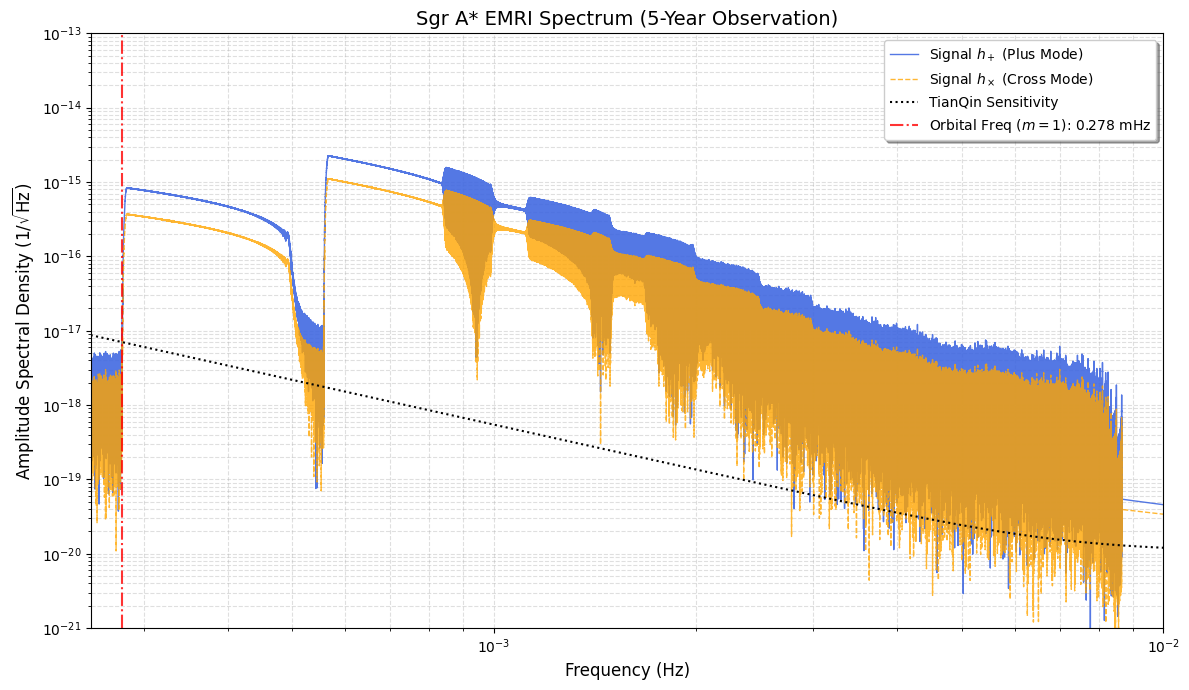

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import get_window

# ==========================================
# 0. 核心处理函数 (以防你需要重新定义)
# ==========================================
def get_asd(time_series, dt):
    N = len(time_series)
    window = get_window(('tukey', 0.1), N)
    data_fft = np.fft.rfft(time_series * window)
    freqs = np.fft.rfftfreq(N, d=dt)
    win_factor = np.sqrt(np.mean(window**2))
    norm_factor = np.sqrt(2 * dt / N) / win_factor
    return freqs, np.abs(data_fft) * norm_factor

# ==========================================
# 1. 计算 FFT (如果你还没算)
# ==========================================
print("正在计算 5 年数据的 ASD...")
f_axis, hp_asd = get_asd(hp, delta_t)
f_axis, hc_asd = get_asd(hc, delta_t)

# ==========================================
# 2. 设置关键参数
# ==========================================
# 物理计算得出的真实基频 (Orbital Frequency)
# Calculation: f ~ (c^3/2piGM) * p^-1.5
# M=4.3e6, p=9  => f ~ 0.278 mHz
f_start_phys = 0.278e-3  

# 剪裁阈值 (Cut-off)
# 设置在基频左边一点点，把低频的数值噪声切掉，但保留基频的完整形态
cut_off_f = 0.25e-3      

# ==========================================
# 3. 数据清洗 (Masking)
# ==========================================
mask = f_axis >= cut_off_f

f_clean = f_axis[mask]
hp_clean = hp_asd[mask]
hc_clean = hc_asd[mask]

# ==========================================
# 4. 绘图
# ==========================================
plt.figure(figsize=(12, 7))

# --- 绘制信号 ---
# alpha=0.8 让颜色饱和一点，linewidth=1 保证细节清晰
plt.loglog(f_clean, hp_clean, label=r'Signal $h_+$ (Plus Mode)', color='royalblue', alpha=0.9, linewidth=1)
plt.loglog(f_clean, hc_clean, label=r'Signal $h_\times$ (Cross Mode)', color='orange', alpha=0.8, linewidth=1, linestyle='--')

# --- 绘制天琴灵敏度 (噪声) ---
# 限制噪声曲线的显示范围，使其与信号对齐
mask_noise = f_axis >= 1e-4 
plt.loglog(f_axis[mask_noise], tq_noise[mask_noise], label='TianQin Sensitivity', color='black', linestyle=':', linewidth=1.5)

# --- 标注基频 (The Start Line) ---
# 这条红线现在标记的是物理上的“轨道频率”
label_text = f'Orbital Freq ($m=1$): {f_start_phys*1000:.3f} mHz'
plt.axvline(x=f_start_phys, color='red', linestyle='-.', linewidth=1.5, alpha=0.8, label=label_text)

# --- 视觉微调 ---
# X轴：从 0.25 mHz 到 10 mHz，完美覆盖信号区
plt.xlim(cut_off_f, 1e-2)  
# Y轴：根据信号强度自动适应
plt.ylim(1e-21, 1e-13)

# 标签与图例
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel(r'Amplitude Spectral Density ($1/\sqrt{\rm{Hz}}$)', fontsize=12)
plt.title(f'Sgr A* EMRI Spectrum (5-Year Observation)', fontsize=14)

# 图例放在右上角，带阴影框，看起来更正式
plt.legend(loc='upper right', fontsize=10, frameon=True, shadow=True, fancybox=True)

plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()

print(f"绘图完成。红线已修正为: {f_start_phys*1000:.3f} mHz")
plt.show()

当前观测时长: 24.0 小时


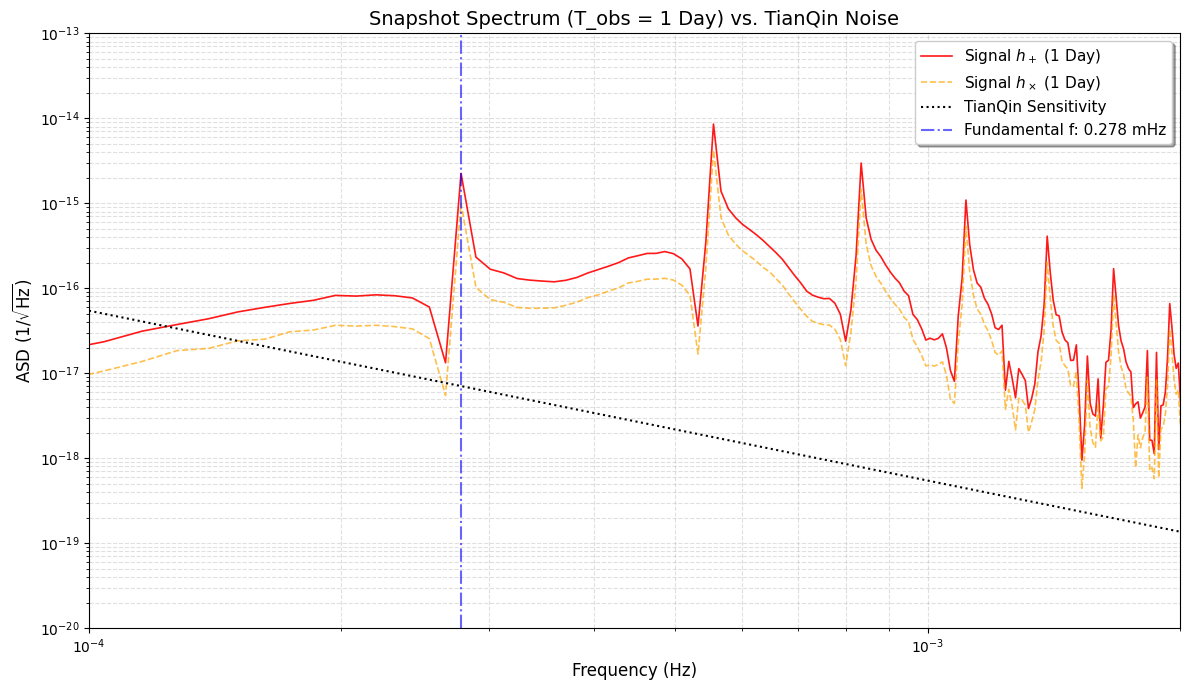

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import get_window

# ==========================================
# 1. 准备数据：截取前 1 天 (86400秒)
# ==========================================
T_obs = 1.0 * 24 * 3600  # 1天
n_slice = int(T_obs / delta_t)

# 截取时域数据
hp_1day = hp[:n_slice]
hc_1day = hc[:n_slice]

print(f"当前观测时长: {T_obs/3600:.1f} 小时")

# ==========================================
# 2. 定义 ASD 计算函数
# ==========================================
def get_asd(time_series, dt):
    N = len(time_series)
    window = get_window(('tukey', 0.1), N)
    data_fft = np.fft.rfft(time_series * window)
    freqs = np.fft.rfftfreq(N, d=dt)
    win_factor = np.sqrt(np.mean(window**2))
    norm_factor = np.sqrt(2 * dt / N) / win_factor
    return freqs, np.abs(data_fft) * norm_factor

# 计算信号 ASD
f_1day, hp_asd = get_asd(hp_1day, delta_t)
f_1day, hc_asd = get_asd(hc_1day, delta_t)

# ==========================================
# 3. 定义并计算天琴灵敏度 (噪声曲线)
# ==========================================
def tianqin_sensitivity(f):
    L = 1.7e8           # 臂长
    f_star = 3e8 / (2 * np.pi * L)
    Sa = 1e-30          # 加速度噪声
    Sx = 1e-24          # 位移噪声
    f = np.maximum(f, 1e-10) # 防止除0
    Sn = (10 / (3 * L**2)) * (4 * Sa / (2 * np.pi * f)**4 + Sx) * (1 + 0.6 * (f / f_star)**2)
    return np.sqrt(Sn)

# 生成一条平滑的噪声曲线用于绘图
f_noise = np.logspace(np.log10(1e-4), np.log10(1e-2), 1000)
asd_noise = tianqin_sensitivity(f_noise)

# ==========================================
# 4. 绘图 (包含灵敏度曲线)
# ==========================================
plt.figure(figsize=(12, 7))

# --- A. 绘制信号 ---
plt.loglog(f_1day, hp_asd, label=r'Signal $h_+$ (1 Day)', color='red', alpha=0.9, linewidth=1.2)
plt.loglog(f_1day, hc_asd, label=r'Signal $h_\times$ (1 Day)', color='orange', alpha=0.7, linewidth=1.2, linestyle='--')

# --- B. 绘制天琴灵敏度曲线 (关键部分) ---
plt.loglog(f_noise, asd_noise, label='TianQin Sensitivity', color='black', linestyle=':', linewidth=1.5)

# --- C. 标注基频位置 ---
# 理论基频 (m=1)
f_fund = 0.278e-3  
plt.axvline(x=f_fund, color='blue', linestyle='-.', alpha=0.6, label=f'Fundamental f: {f_fund*1000:.3f} mHz')

# --- D. 调整显示范围与装饰 ---
plt.xlim(1e-4, 2e-3)    # 聚焦在低频段，看清尖峰
plt.ylim(1e-20, 1e-13)  # Y轴范围

plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel(r'ASD ($1/\sqrt{\rm{Hz}}$)', fontsize=12)
plt.title(f'Snapshot Spectrum (T_obs = 1 Day) vs. TianQin Noise', fontsize=14)

# 图例
plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=11)
plt.grid(True, which='both', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()